In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [ ]:
import kagglehub
path = kagglehub.dataset_download("fedesoriano/stellar-classification-dataset-sdss17")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'stellar-classification-dataset-sdss17' dataset.
Path to dataset files: /kaggle/input/stellar-classification-dataset-sdss17


In [ ]:
df = pd.read_csv(f"{path}/star_classification.csv")

df.head()
df.shape
df.info()
df["class"].value_counts()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


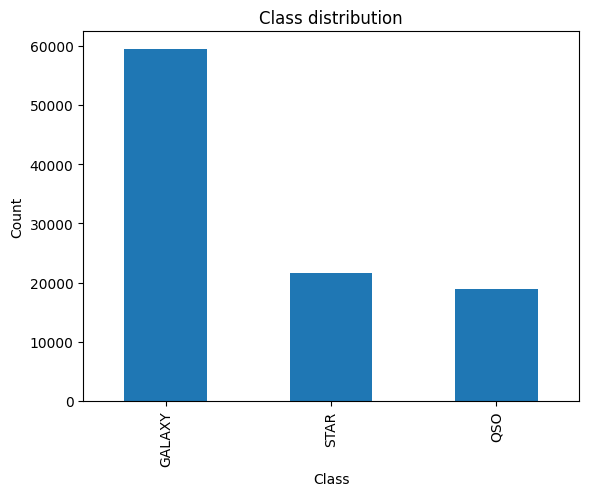

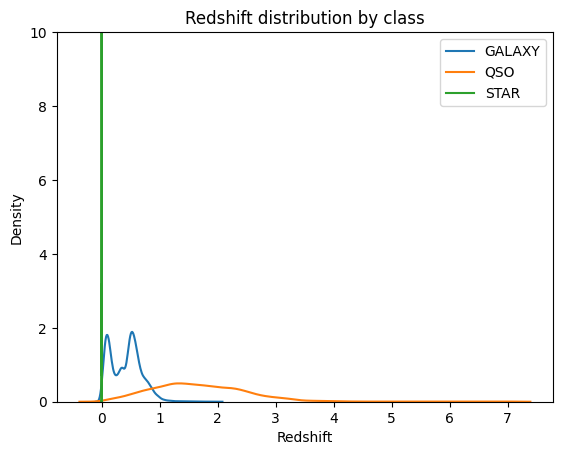

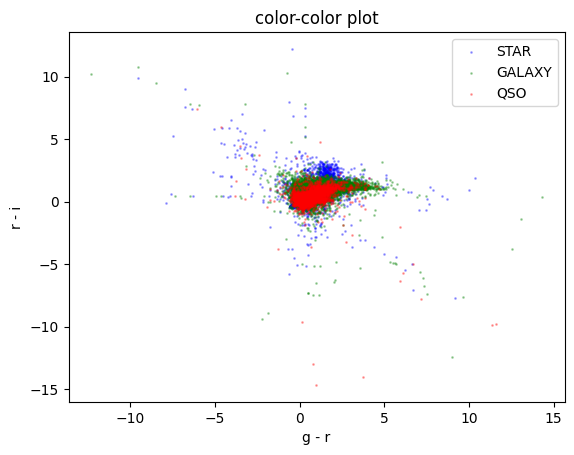

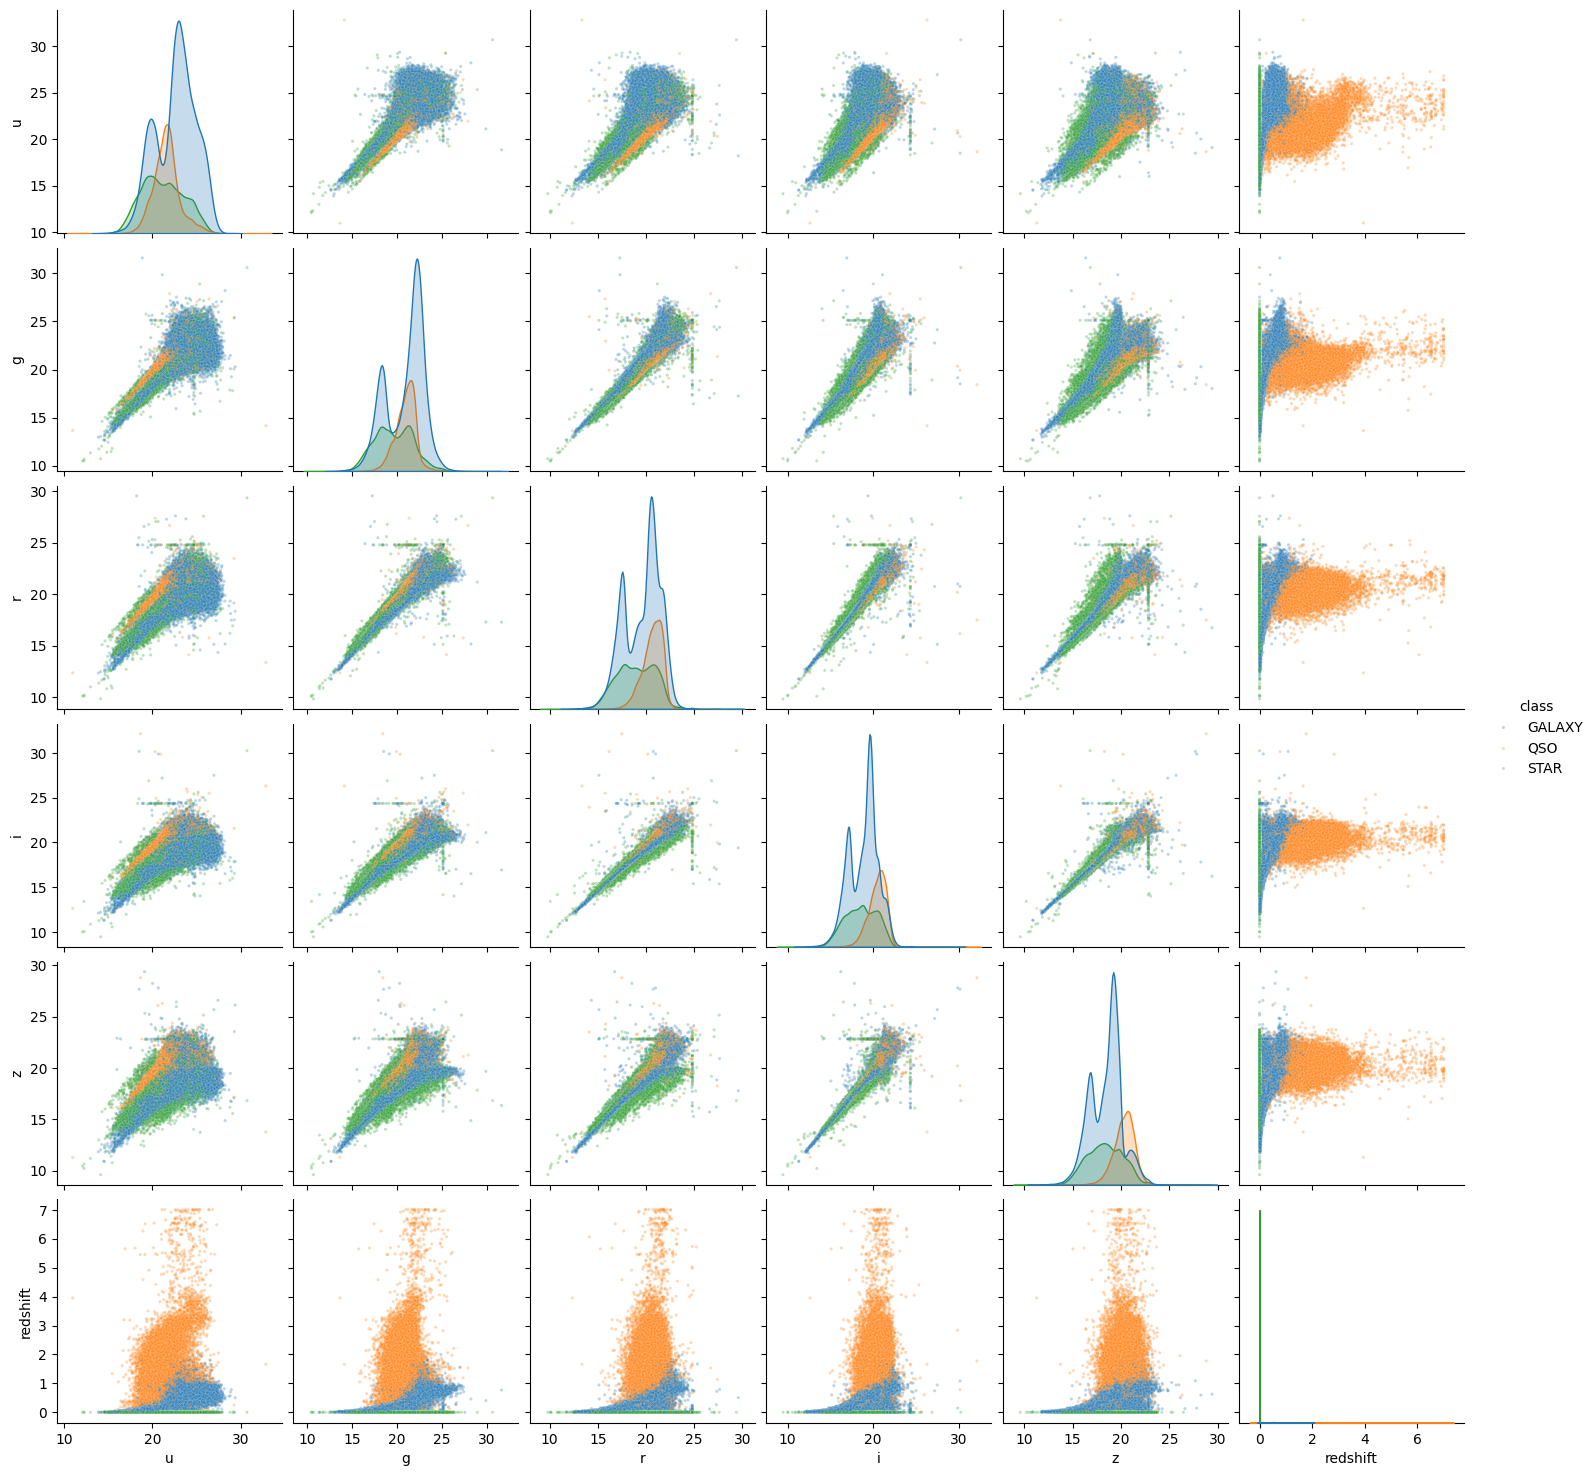

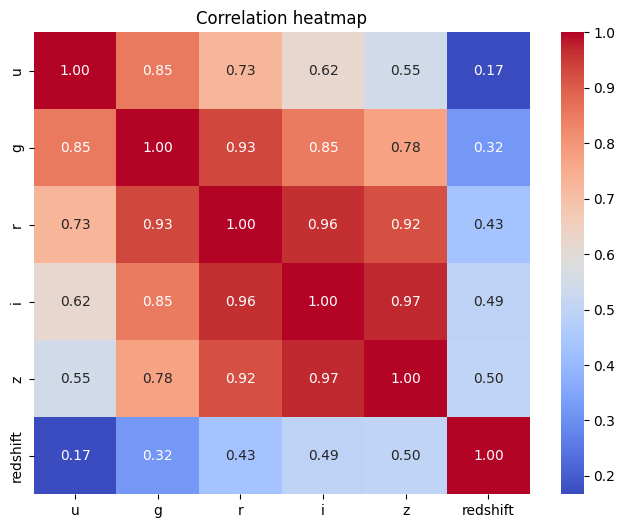

In [ ]:
df['class'].value_counts().plot(kind='bar')
plt.title("Class distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

for label in df['class'].unique():
  subset = df[df['class'] == label]
  sns.kdeplot(subset["redshift"],label=label)
plt.ylim(0,10)
plt.title("Redshift distribution by class")
plt.xlabel("Redshift")
plt.legend()
plt.show()

df['g_r'] = df['g'] - df['r']
df['r_i'] = df['r'] - df['i']
colors = {'STAR': 'blue', 'GALAXY': 'green', 'QSO': 'red'}
for label,color in colors.items():
  subset = df[df['class'] == label]
  plt.scatter(subset['g_r'], subset['r_i'], label=label, color=color, alpha=0.3, s=1)
plt.xlabel('g - r')
plt.ylabel('r - i')
plt.title("color-color plot")
plt.legend()
plt.show()

cols = ["u", "g", "r", "i", "z", "redshift", "class"]

sns.pairplot(df[cols], hue="class", plot_kws={"alpha": 0.3, "s": 5})
plt.show()

# Pick only numeric columns
numeric_cols = ["u", "g", "r", "i", "z", "redshift"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(),
            annot=True,       # shows the number inside each cell
            fmt=".2f",        # 2 decimal places
            cmap="coolwarm")  # blue = negative, red = positive correlation
plt.title("Correlation heatmap")
plt.show()

In [ ]:
(df[["u", "g", "z"]] < -100).sum()

df[["u", "g", "z"]] = df[["u", "g", "z"]].replace(-9999, np.nan)
df.dropna(inplace=True)
print(df.shape)  # check how many rows remain

(99999, 20)


In [ ]:
print(df.isnull().sum())

le = LabelEncoder()
df['class_encoded'] = le.fit_transform(df['class'])

X = df.drop(columns=['run_ID','rerun_ID','cam_col','field_ID','alpha','delta','obj_ID','spec_obj_ID','fiber_ID','plate','MJD','class','class_encoded'])
y = df['class_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
g_r            0
r_i            0
dtype: int64
(79999, 8) (20000, 8)


In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision TreeAccuracy: ", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

Decision TreeAccuracy:  0.9672
              precision    recall  f1-score   support

      GALAXY       0.97      0.97      0.97     11889
         QSO       0.92      0.92      0.92      3792
        STAR       1.00      0.99      1.00      4319

    accuracy                           0.97     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.97      0.97      0.97     20000



In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy: ", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Random Forest Accuracy:  0.97925
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       0.99      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



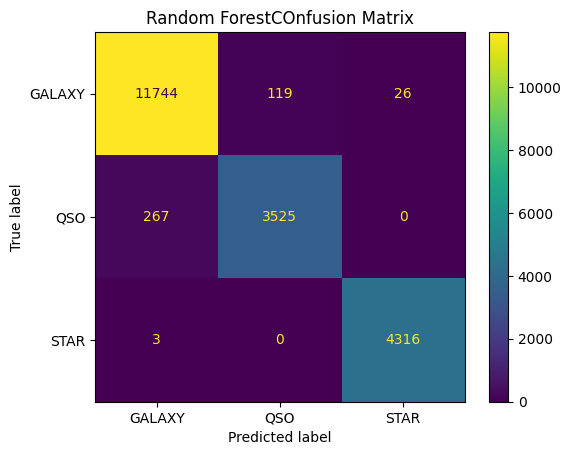

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=le.classes_
)
plt.title("Random ForestCOnfusion Matrix")
plt.show()

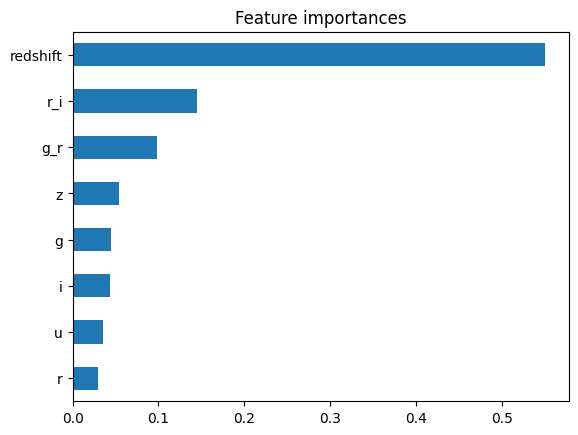

In [ ]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind="barh")
plt.title("Feature importances")
plt.show()